# Ball Detection & Tracking — Data Preparation Pipeline

Import Libraries

In [ ]:
import cv2
import numpy as np
import pandas as pd
import torch
from google.colab import drive
import os
import torch.nn as nn


Mount Google Drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


Loading & Extracting the Data

In [3]:
!find /content/drive/MyDrive -iname "*TrackNetV2*"
!unzip -q "/content/drive/MyDrive/TrackNetV2.zip" -d /content/TrackNetV2

/content/drive/MyDrive/TrackNetV2.zip


In [4]:
!find /content/TrackNetV2 -maxdepth 4 | head -30

/content/TrackNetV2
/content/TrackNetV2/TrackNetV2
/content/TrackNetV2/TrackNetV2/Professional
/content/TrackNetV2/TrackNetV2/Professional/match7
/content/TrackNetV2/TrackNetV2/Professional/match7/video
/content/TrackNetV2/TrackNetV2/Professional/match7/csv
/content/TrackNetV2/TrackNetV2/Professional/match16
/content/TrackNetV2/TrackNetV2/Professional/match16/video
/content/TrackNetV2/TrackNetV2/Professional/match16/csv
/content/TrackNetV2/TrackNetV2/Professional/match4
/content/TrackNetV2/TrackNetV2/Professional/match4/video
/content/TrackNetV2/TrackNetV2/Professional/match4/csv
/content/TrackNetV2/TrackNetV2/Professional/match17
/content/TrackNetV2/TrackNetV2/Professional/match17/video
/content/TrackNetV2/TrackNetV2/Professional/match17/csv
/content/TrackNetV2/TrackNetV2/Professional/match15
/content/TrackNetV2/TrackNetV2/Professional/match15/video
/content/TrackNetV2/TrackNetV2/Professional/match15/csv
/content/TrackNetV2/TrackNetV2/Professional/match9
/content/TrackNetV2/TrackNetV2

Inspect Labels

In [5]:
LABEL_DIR = "/content/TrackNetV2/TrackNetV2/Amateur/match1/csv/1_00_01_ball.csv"
label = pd.read_csv(LABEL_DIR)
label.head(20)

,Frame,Visibility,X,Y
0,0,0,0,0
1,1,0,0,0
2,2,0,0,0
3,3,0,0,0
4,4,0,0,0
5,5,0,0,0
6,6,0,0,0
7,7,0,0,0
8,8,0,0,0
9,9,0,0,0


In [6]:
print(label['Visibility'].unique())
print(label.columns.tolist())

[0 1]
['Frame', 'Visibility', 'X', 'Y']


Inspect Video Properties

In [7]:
IMG_PATH = "/content/TrackNetV2/TrackNetV2/Amateur/match1/video/1_00_01.mp4"
video = cv2.VideoCapture(IMG_PATH)
if not video.isOpened():
    print("Error: Could not open video.")
else:
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    fps    = video.get(cv2.CAP_PROP_FPS)
    print(f"Resolution : {width} X {height}")
    print(f"FPS:         {fps}")

Resolution : 1280 X 720
FPS:         30.0


In [8]:
!ls /content/TrackNetV2/TrackNetV2/Amateur/match1/video
!ls /content/TrackNetV2/TrackNetV2/Amateur/match1/csv

1_00_01.mp4  1_01_02.mp4  1_01_04.mp4  1_03_04.mp4  1_04_05.mp4
1_01_01.mp4  1_01_03.mp4  1_02_04.mp4  1_03_05.mp4  1_05_05.mp4
1_00_01_ball.csv  1_01_03_ball.csv  1_03_04_ball.csv  1_05_05_ball.csv
1_01_01_ball.csv  1_01_04_ball.csv  1_03_05_ball.csv
1_01_02_ball.csv  1_02_04_ball.csv  1_04_05_ball.csv


Extract Frames from Videos

In [9]:
VIDEOS_DIR = "/content/TrackNetV2/TrackNetV2/"
FRAMES_BASE_OUTPUT = "/content/frames_output"

def extract_frames(video_path, output_dir):
  os.makedirs(output_dir, exist_ok=True)
  cap = cv2.VideoCapture(video_path)
  if not cap.isOpened():
      print(f"Error: Could not open video {video_path}")
      return 0

  print(f"Extracting frames from: {video_path} to {output_dir}")
  i = 0
  while True:
    ret, frame = cap.read()
    if not ret:
      break
    cv2.imwrite(os.path.join(output_dir, f"frame_{i:05d}.jpg"), frame)
    i += 1
  cap.release()
  print(f"Extracted {i} frames.")
  return i

for dirpath, dirnames, filenames in os.walk(VIDEOS_DIR):
  for filename in filenames:
    if filename.endswith(".mp4"):
      video_file_path = os.path.join(dirpath, filename)
      relative_path = os.path.relpath(video_file_path, VIDEOS_DIR)
      video_output_dir = os.path.join(FRAMES_BASE_OUTPUT, os.path.dirname(relative_path), os.path.splitext(filename)[0])

      extract_frames(video_file_path, video_output_dir)

Extracting frames from: /content/TrackNetV2/TrackNetV2/Professional/match7/video/1_12_13.mp4 to /content/frames_output/Professional/match7/video/1_12_13
Extracted 620 frames.
Extracting frames from: /content/TrackNetV2/TrackNetV2/Professional/match7/video/2_05_03.mp4 to /content/frames_output/Professional/match7/video/2_05_03
Extracted 945 frames.
Extracting frames from: /content/TrackNetV2/TrackNetV2/Professional/match7/video/2_14_15.mp4 to /content/frames_output/Professional/match7/video/2_14_15
Extracted 494 frames.
Extracting frames from: /content/TrackNetV2/TrackNetV2/Professional/match7/video/1_02_01.mp4 to /content/frames_output/Professional/match7/video/1_02_01
Extracted 648 frames.
Extracting frames from: /content/TrackNetV2/TrackNetV2/Professional/match7/video/3_08_05.mp4 to /content/frames_output/Professional/match7/video/3_08_05
Extracted 454 frames.
Extracting frames from: /content/TrackNetV2/TrackNetV2/Professional/match16/video/2_08_08.mp4 to /content/frames_output/Profe

Build Sliding-Window Frame Triplets (Truncated to CSV Length)

In [10]:
WINDOW_SIZE = 3

samples = []

for dirpath, dirnames, filenames in os.walk(FRAMES_BASE_OUTPUT):
    if dirnames:
        continue

    frame_files = sorted(f for f in filenames if f.lower().endswith((".jpg", ".jpeg", ".png")))
    if not frame_files:
        continue

    rel_path = os.path.relpath(dirpath, FRAMES_BASE_OUTPUT)
    parts = rel_path.split(os.sep)
    clip_name = parts[-1]
    csv_parts = ["csv" if p == "video" else p for p in parts[:-1]]
    csv_path = os.path.join(VIDEOS_DIR, *csv_parts, f"{clip_name}_ball.csv")

    if not os.path.exists(csv_path):
        continue

    clip_labels = pd.read_csv(csv_path)

    n = len(clip_labels)
    frame_paths = [os.path.join(dirpath, f) for f in frame_files[:n]]

    for i in range(len(frame_paths) - WINDOW_SIZE + 1):
        frame_path_1, frame_path_2, frame_path_3 = frame_paths[i], frame_paths[i + 1], frame_paths[i + 2]
        label_1 = tuple(clip_labels.iloc[i][["Visibility", "X", "Y"]])
        label_2 = tuple(clip_labels.iloc[i + 1][["Visibility", "X", "Y"]])
        label_3 = tuple(clip_labels.iloc[i + 2][["Visibility", "X", "Y"]])
        samples.append((frame_path_1, frame_path_2, frame_path_3, label_1, label_2, label_3))

print(f"Built {len(samples)} sliding-window triplets from {FRAMES_BASE_OUTPUT}")

Built 90812 sliding-window triplets from /content/frames_output


In [11]:
class TrackNetDataset(torch.utils.data.Dataset):
    def __init__(self, samples, resize_to=(512, 288)):
      self.samples = samples
      self.resize_to = resize_to

    def __len__(self):
      return len(self.samples)

    def __getitem__(self, idx):
      frame_path_1, frame_path_2, frame_path_3, label_1, label_2, label_3 = self.samples[idx]

      new_w, new_h = self.resize_to
      images = []
      labels = []
      for frame_path, label in zip((frame_path_1, frame_path_2, frame_path_3), (label_1, label_2, label_3)):
        image = cv2.imread(frame_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = image.shape[:2]
        image = cv2.resize(image, self.resize_to, interpolation=cv2.INTER_AREA)
        images.append(image.transpose(2, 0, 1))

        visibility, x, y = label
        scale_x = new_w / orig_w
        scale_y = new_h / orig_h
        labels.append((visibility, x * scale_x, y * scale_y))

      images = np.concatenate(images, axis=0)
      labels = np.array(labels, dtype=np.float32)

      return torch.from_numpy(images), torch.from_numpy(labels)

In [30]:
from matplotlib import pyplot as plt

dataset = TrackNetDataset(samples)
images, labels = dataset[15]


print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

Images shape: torch.Size([9, 288, 512])
Labels shape: torch.Size([3, 3])


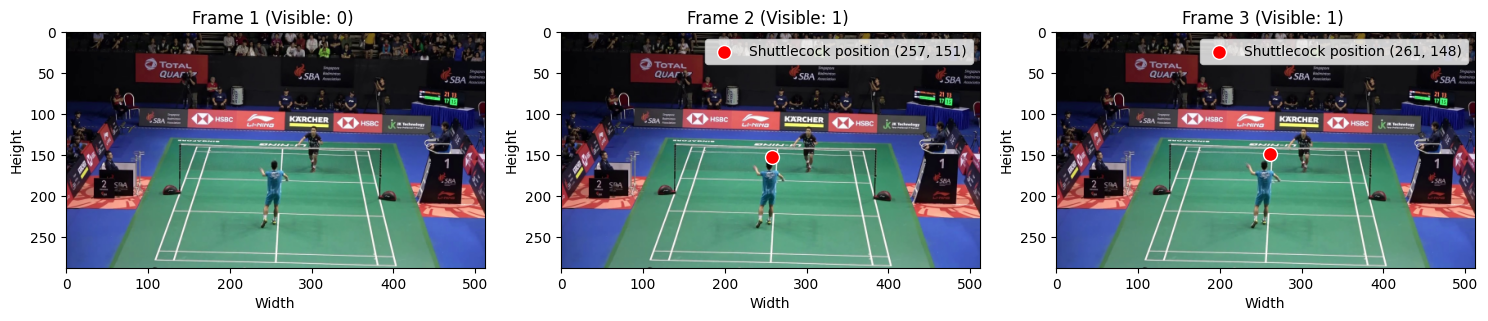

In [29]:
import math

cols = 3
num_samples_to_fetch = 2
total_frames_to_plot = num_samples_to_fetch * 3
rows = math.ceil(total_frames_to_plot / cols)
plt.figure(figsize=(cols * 5, rows * 5))

frame_counter = 0
for sample_idx in range(num_samples_to_fetch):
    if sample_idx >= len(dataset):
        print(f"Warning: Dataset only has {len(dataset)} samples. Plotting fewer than requested.")
        break

    images_from_sample, labels_from_sample = dataset[sample_idx]

    for i in range(3):
        if frame_counter >= total_frames_to_plot:
            break

        img_to_show = images_from_sample[i*3:(i*3)+3].permute(1, 2, 0).numpy()
        visibility, x, y = labels_from_sample[i].tolist()

        plt.subplot(rows, cols, frame_counter + 1)
        plt.imshow(img_to_show)
        plt.title(f"Sample {sample_idx}, Frame {i+1} (Visible: {int(visibility)})")
        plt.xlabel("Width")
        plt.ylabel("Height")


        if visibility == 1:
            plt.scatter(x, y, color='red', marker='o', s=100, edgecolors='white', linewidth=1, label=f'Shuttlecock position ({int(x)}, {int(y)})')
            plt.legend(loc='upper right')

        frame_counter += 1
    if frame_counter >= total_frames_to_plot:
        break

plt.tight_layout()
plt.show()

Generate Gaussian Heatmaps for Ball Position

In [ ]:
HEATMAP_SIGMA = 5

def generate_heatmap(x, y, visibility, H, W, sigma=HEATMAP_SIGMA):
    if not visibility:
        return np.zeros((H, W), dtype=np.float32)

    cols, rows = np.meshgrid(np.arange(W), np.arange(H))
    heatmap = np.exp(-((cols - x) ** 2 + (rows - y) ** 2) / (2 * sigma ** 2))
    return heatmap.astype(np.float32)

In [ ]:
images, labels = dataset[15]
H, W = dataset.resize_to[1], dataset.resize_to[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    visibility, x, y = labels[i].tolist()
    heatmap = generate_heatmap(x, y, visibility, H, W)

    img_to_show = images[i*3:(i*3)+3].permute(1, 2, 0).numpy()
    ax.imshow(img_to_show)
    ax.imshow(heatmap, cmap='jet', alpha=0.5)
    ax.set_title(f"Frame {i+1} (Visible: {int(visibility)}), heatmap max={heatmap.max():.2f}")

plt.tight_layout()
plt.show()

VGG-Style Encoder

In [ ]:
encoder_block1 = nn.Sequential(
    nn.Conv2d(9, 64, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

encoder_block2 = nn.Sequential(
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 128, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

encoder_block3 = nn.Sequential(
    nn.Conv2d(128, 256, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

encoder_block4 = nn.Sequential(
    nn.Conv2d(256, 512, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(512, 512, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(512, 512, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2)
)

In [ ]:
images, labels = dataset[15]
x = images.unsqueeze(0).float()

out1 = encoder_block1(x)
out2 = encoder_block2(out1)
skip3 = encoder_block3(out2)
bottleneck = encoder_block4(skip3)

print(f"Input shape:      {x.shape}")
print(f"Block1 output:    {out1.shape}")
print(f"Block2 output:    {out2.shape}")
print(f"Block3 output (skip): {skip3.shape}")
print(f"Block4 output (bottleneck): {bottleneck.shape}")

Decoder Block 1 — Upsample (18×32 → 36×64) + Skip from Block 3

In [ ]:
decoder_block1_upsample = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
decoder_block1_conv = nn.Sequential(
    nn.Conv2d(512, 256, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
)
decoder_block2_upsample = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
decoder_block2_conv = nn.Sequential(
    nn.Conv2d(256, 128, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(128, 128, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
)

decoder_block3_upsample = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
decoder_block3_conv = nn.Sequential(
    nn.Conv2d(128, 64, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),
)
decoder_block4_upsample = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
final_conv = nn.Sequential(
    nn.Conv2d(32, 3, kernel_size=1),
    nn.Sigmoid()
)